# Middle‑Fusion Training Pipeline
**GNN → LSTM (Attention) for Fraudulent Smart‑Contract Detection**

Complete example: data loading, model definition, training loop, metrics, and checkpointing.

## Imports

In [1]:
import os, glob, time
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm


## Model components

In [2]:
class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.25):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        return global_mean_pool(x, batch)


In [3]:
class AttentionPool(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.W = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, 1, bias=False)
    def forward(self, lstm_out, lengths):
        scores = self.v(torch.tanh(self.W(lstm_out))).squeeze(-1)
        mask = torch.arange(lstm_out.size(1), device=lengths.device)[None, :] < lengths[:, None]
        scores = scores.masked_fill(~mask, -1e9)
        attn = torch.softmax(scores, dim=1)
        context = torch.bmm(attn.unsqueeze(1), lstm_out).squeeze(1)
        return context


In [4]:
class GNN_LSTM_Attn(nn.Module):
    def __init__(self, gnn_encoder, gnn_out, lstm_hidden, lstm_layers, num_classes, freeze_gnn=True, dropout=0.5):
        super().__init__()
        self.gnn = gnn_encoder
        if freeze_gnn:
            for p in self.gnn.parameters():
                p.requires_grad_(False)
        self.lstm = nn.LSTM(gnn_out, lstm_hidden, num_layers=lstm_layers, batch_first=True)
        self.attn = AttentionPool(lstm_hidden)
        self.clf = nn.Sequential(nn.Dropout(dropout), nn.Linear(lstm_hidden, num_classes))
    def forward(self, graph_seqs, seq_lengths):
        B, T = len(graph_seqs), len(graph_seqs[0])
        device = seq_lengths.device
        embeds = []
        for t in range(T):
            batch_t = Batch.from_data_list([seq[t] for seq in graph_seqs]).to(device)
            e = self.gnn(batch_t.x, batch_t.edge_index, batch_t.batch)
            embeds.append(e.unsqueeze(1))
        seq = torch.cat(embeds, 1)  # [B,T,D]
        packed = nn.utils.rnn.pack_padded_sequence(seq, seq_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=T)
        ctx = self.attn(lstm_out, seq_lengths)
        return self.clf(ctx)


In [5]:
def build_model(in_dim=139, gnn_hidden=64, gnn_out=128, lstm_hid=256, lstm_layers=2, num_classes=2):
    gnn = GraphSAGEEncoder(in_dim, gnn_hidden, gnn_out)
    return GNN_LSTM_Attn(gnn, gnn_out, lstm_hid, lstm_layers, num_classes, freeze_gnn=True)


## Dataset and dataloader

In [6]:
class GraphSeqDataset(Dataset):
    def __init__(self, files):
        self.files = files
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        sample = torch.load(self.files[idx])
        return sample['graph_seq'], len(sample['graph_seq']), sample['label']


In [7]:
def collate(batch):
    seqs, lengths, labels = zip(*batch)
    max_len = max(lengths)
    padded = [seq + [seq[-1]]*(max_len-len(seq)) for seq in seqs]
    return padded, torch.tensor(lengths), torch.tensor(labels)


## Training utils

In [8]:
def epoch_run(model, loader, crit, opt=None, device='cpu'):
    train = opt is not None
    model.train() if train else model.eval()
    tot, ys, ps = 0.0, [], []
    for seqs, lens, labels in tqdm(loader):
        labels, lens = labels.to(device), lens.to(device)
        if train: opt.zero_grad()
        with torch.set_grad_enabled(train):
            out = model(seqs, lens)
            loss = crit(out, labels)
            if train:
                loss.backward(); opt.step()
        tot += loss.item()*labels.size(0)
        ys.extend(labels.cpu().numpy())
        ps.extend(out.argmax(1).cpu().numpy())
    acc = accuracy_score(ys, ps); f1 = f1_score(ys, ps, average='macro')
    return tot/len(loader.dataset), acc, f1


## Config & training loop

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch
import os, glob

# 📌 Метрики
val_losses, val_accs, val_f1s, val_rocs = [], [], [], []
test_losses, test_accs, test_f1s, test_rocs = [], [], [], []

# 📌 ROC-AUC поддержка
def get_preds_labels(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            seqs, lens, labels = batch
            seqs = [[g.to(device) for g in seq] for seq in seqs]
            out = model(seqs, lens)  # [B, 2]
            probs = torch.softmax(out, dim=1)[:, 1]  # prob of class 1
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_probs).numpy(), torch.cat(all_labels).numpy()

# 📌 Визуализация
def plot_all_metrics(val_metrics, test_metrics, title_prefix):
    keys = ['Loss', 'Accuracy', 'F1', 'ROC-AUC']
    for i, key in enumerate(keys):
        plt.figure(figsize=(7, 4))
        plt.plot(val_metrics[i], label='Val')
        plt.plot(test_metrics[i], label='Test')
        plt.title(f"{title_prefix} — {key}")
        plt.xlabel("Epoch")
        plt.ylabel(key)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
DATA_ROOT = '/Users/a1234/Fraud/gnn/gnn_middle'
train_files = glob.glob(os.path.join(DATA_ROOT, 'train', '*.pt'))
val_files   = glob.glob(os.path.join(DATA_ROOT, 'val', '*.pt'))
test_files  = glob.glob(os.path.join(DATA_ROOT, 'test', '*.pt'))

BATCH = 8
EPOCHS = 30
LR = 1e-3
# EarlyStopping параметры
PATIENCE = 7
patience_counter = 0
best_val_f1 = 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader = DataLoader(GraphSeqDataset(train_files), BATCH, True, collate_fn=collate)
val_loader   = DataLoader(GraphSeqDataset(val_files),   BATCH, False, collate_fn=collate)
test_loader  = DataLoader(GraphSeqDataset(test_files),  BATCH, False, collate_fn=collate)

model = build_model().to(device)
opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
crit = torch.nn.CrossEntropyLoss()

best = 0
for e in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = epoch_run(model, train_loader, crit, opt, device)
    val_loss, val_acc, val_f1 = epoch_run(model, val_loader, crit, None, device)

    print(f'E{e} | tr {tr_loss:.3f}/{tr_acc:.3f}/{tr_f1:.3f} | val {val_loss:.3f}/{val_acc:.3f}/{val_f1:.3f}')
    
    if val_f1 > best:
        best=val_f1; torch.save(model.state_dict(),'best_middle_fusion.pt'); print('✅ saved')

    # if val_f1 > best_val_f1:
    #     best_val_f1 = val_f1
    #     patience_counter = 0
    #     torch.save(model.state_dict(), 'best_middle_fusion.pt')
    #     print('✅ saved new best')
    # else:
    #     patience_counter += 1
    #     if patience_counter >= PATIENCE:
    #         print(f'⏹️ Early stopping at epoch {e} (no improvement in {PATIENCE} epochs)')
    #         break


    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    val_preds, val_labels = get_preds_labels(model, val_loader, device)
    val_roc = roc_auc_score(val_labels, val_preds)
    val_rocs.append(val_roc)

    # 💡 Тестовые метрики (на каждой эпохе, для графиков)
    test_loss, test_acc, test_f1 = epoch_run(model, test_loader, crit, None, device)
    test_preds, test_labels = get_preds_labels(model, test_loader, device)
    test_roc = roc_auc_score(test_labels, test_preds)
    
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    test_f1s.append(test_f1)
    test_rocs.append(test_roc)



100%|██████████| 53/53 [00:00<00:00, 109.54it/s]


E1 | tr 0.593/0.694/0.693 | val 0.492/0.798/0.795
✅ saved


100%|██████████| 53/53 [00:00<00:00, 147.14it/s]


E2 | tr 0.455/0.803/0.803 | val 0.432/0.812/0.811
✅ saved


100%|██████████| 53/53 [00:00<00:00, 184.59it/s]


...

100%|██████████| 53/53 [00:00<00:00, 179.14it/s]


E29 | tr 0.141/0.946/0.946 | val 0.395/0.884/0.884


100%|██████████| 53/53 [00:00<00:00, 182.57it/s]


E30 | tr 0.137/0.948/0.948 | val 0.418/0.867/0.867


100%|██████████| 53/53 [00:00<00:00, 180.83it/s]


100%|██████████| 53/53 [00:00<00:00, 173.13it/s]


TEST  Loss=0.256 Acc=0.893 F1=0.891 ROC-AUC=0.962
              precision    recall  f1-score   support

           0      0.893     0.897     0.895       213
           1      0.893     0.888     0.891       206

    accuracy                          0.893       419
   macro avg      0.893     0.893     0.893       419
weighted avg      0.893     0.893     0.893       419



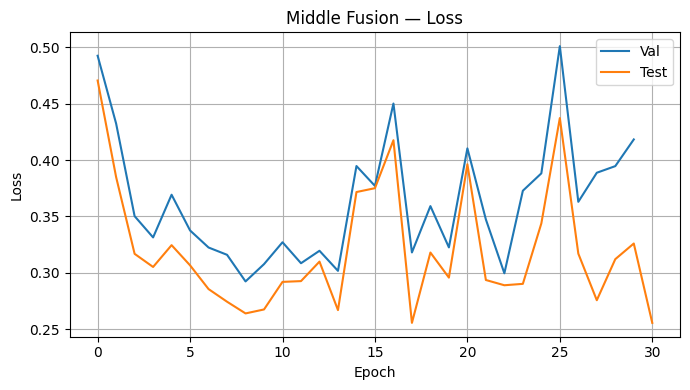

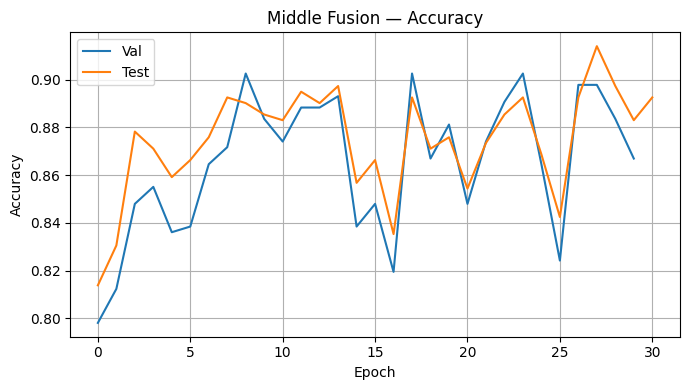

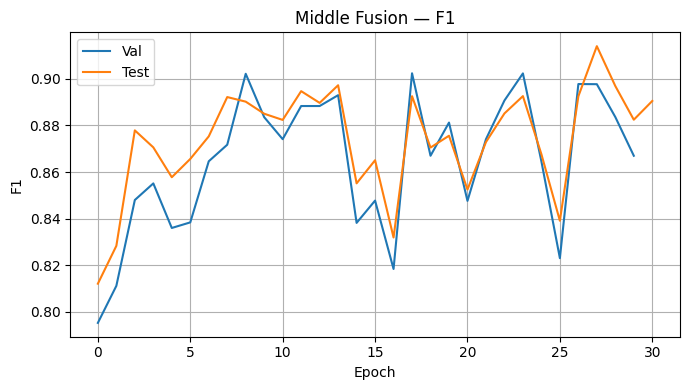

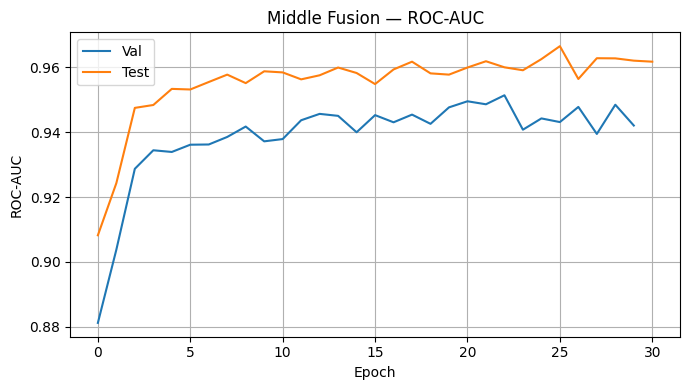

VAL  Loss=0.418 Acc=0.903 F1=0.907 ROC-AUC=0.945
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       205
           1       0.89      0.93      0.91       216

    accuracy                           0.90       421
   macro avg       0.90      0.90      0.90       421
weighted avg       0.90      0.90      0.90       421



In [ ]:
# 📌 Загрузка лучших весов
model.load_state_dict(torch.load('best_middle_fusion.pt'))

# 📌 Оценка
test_loss, test_acc, test_f1 = epoch_run(model, test_loader, crit, None, device)
test_preds, test_labels = get_preds_labels(model, test_loader, device)

test_roc = roc_auc_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds > 0.5)
test_acc = accuracy_score(test_labels, test_preds > 0.5)

print(f'TEST  Loss={test_loss:.3f} Acc={test_acc:.3f} F1={test_f1:.3f} ROC-AUC={test_roc:.3f}')
print(classification_report(test_labels, test_preds > 0.5, digits=3))

# 📌 Сохраняем финальные метрики
test_losses.append(test_loss)
test_accs.append(test_acc)
test_f1s.append(test_f1)
test_rocs.append(test_roc)

# 📈 Графики
plot_all_metrics(
    val_metrics=[val_losses, val_accs, val_f1s, val_rocs],
    test_metrics=[test_losses, test_accs, test_f1s, test_rocs],
    title_prefix="Middle Fusion"
)

# 🔍 Val evaluation (только для отчёта)
val_preds, val_labels = get_preds_labels(model, val_loader, device)
val_roc = roc_auc_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds > 0.5)
val_acc = accuracy_score(val_labels, val_preds > 0.5)

print(f'VAL  Loss={val_losses[-1]:.3f} Acc={val_acc:.3f} F1={val_f1:.3f} ROC-AUC={val_roc:.3f}')
print(classification_report(val_labels, val_preds > 0.5))



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', cbar=True)
    plt.title(f'Confusion Matrix ({title})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


=== Validation Report ===
              precision    recall  f1-score   support

           0      0.918     0.878     0.898       205
           1      0.889     0.926     0.907       216

    accuracy                          0.903       421
   macro avg      0.904     0.902     0.902       421
weighted avg      0.903     0.903     0.903       421



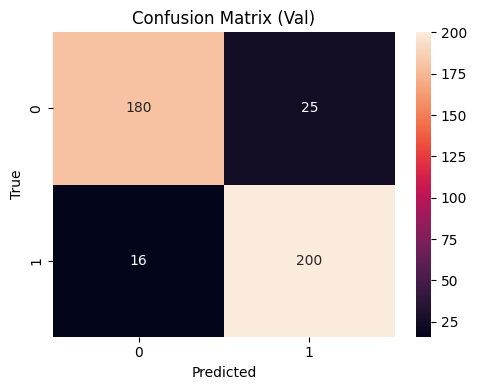

=== Test Report ===
              precision    recall  f1-score   support

           0      0.893     0.897     0.895       213
           1      0.893     0.888     0.891       206

    accuracy                          0.893       419
   macro avg      0.893     0.893     0.893       419
weighted avg      0.893     0.893     0.893       419



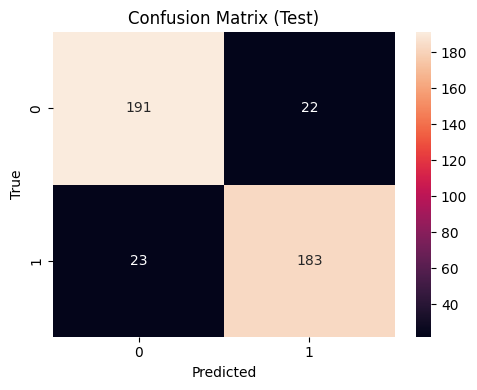

In [ ]:
# === ⏹️ Evaluation after training ===
model.load_state_dict(torch.load('best_middle_fusion.pt'))

# Val
val_preds, val_labels = get_preds_labels(model, val_loader, device)
val_bin_preds = (val_preds > 0.5).astype(int)
print("=== Validation Report ===")
print(classification_report(val_labels, val_bin_preds, digits=3))
plot_confusion_matrix(val_labels, val_bin_preds, title="Val")

# Test
test_preds, test_labels = get_preds_labels(model, test_loader, device)
test_bin_preds = (test_preds > 0.5).astype(int)
print("=== Test Report ===")
print(classification_report(test_labels, test_bin_preds, digits=3))
plot_confusion_matrix(test_labels, test_bin_preds, title="Test")
